In [111]:
# !pip install kydavra
# !pip install imperio

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, LinearRegression
from kydavra import PValueSelector, LassoSelector, PearsonCorrelationSelector, KendallCorrelationSelector, SpearmanCorrelationSelector, PointBiserialCorrSelector
from imblearn.over_sampling import SMOTE
from imperio import TargetImputationTransformer

In [3]:
sns.set_palette('viridis')

# **Load Dataset**

## Dataset 1

[Chosen Dataset](https://www.kaggle.com/datasets/altavish/boston-housing-dataset)

In [4]:
df_bh = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "altavish/boston-housing-dataset",
  "HousingData.csv"
)

Using Colab cache for faster access to the 'boston-housing-dataset' dataset.


## Dataset 2

[Chosen Dataset](https://www.kaggle.com/datasets/neuromusic/avocado-prices?select=avocado.csv)

In [5]:
df_emt = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wkirgsn/electric-motor-temperature",
  "measures_v2.csv"
)

Using Colab cache for faster access to the 'electric-motor-temperature' dataset.


## Dataset 3

[Chosen Dataset](https://www.kaggle.com/datasets/anvarnarz/tashkent-real-estate-2019)

In [6]:
df_tuh = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "anvarnarz/tashkent-real-estate-2019",
  "uybor.xlsx"
)

Using Colab cache for faster access to the 'tashkent-real-estate-2019' dataset.


# **Analyse Dataset**

## Dataset 1

In [7]:
df_bh.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


I will delete NaN values from target column, as it would be bothersome to restore it, because it may affect the score performance of the models.

In [8]:
df_bh = df_bh.dropna(subset=['CHAS'])

In [9]:
df_bh.isna().sum()

,0
CRIM,19
ZN,20
INDUS,19
CHAS,0
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


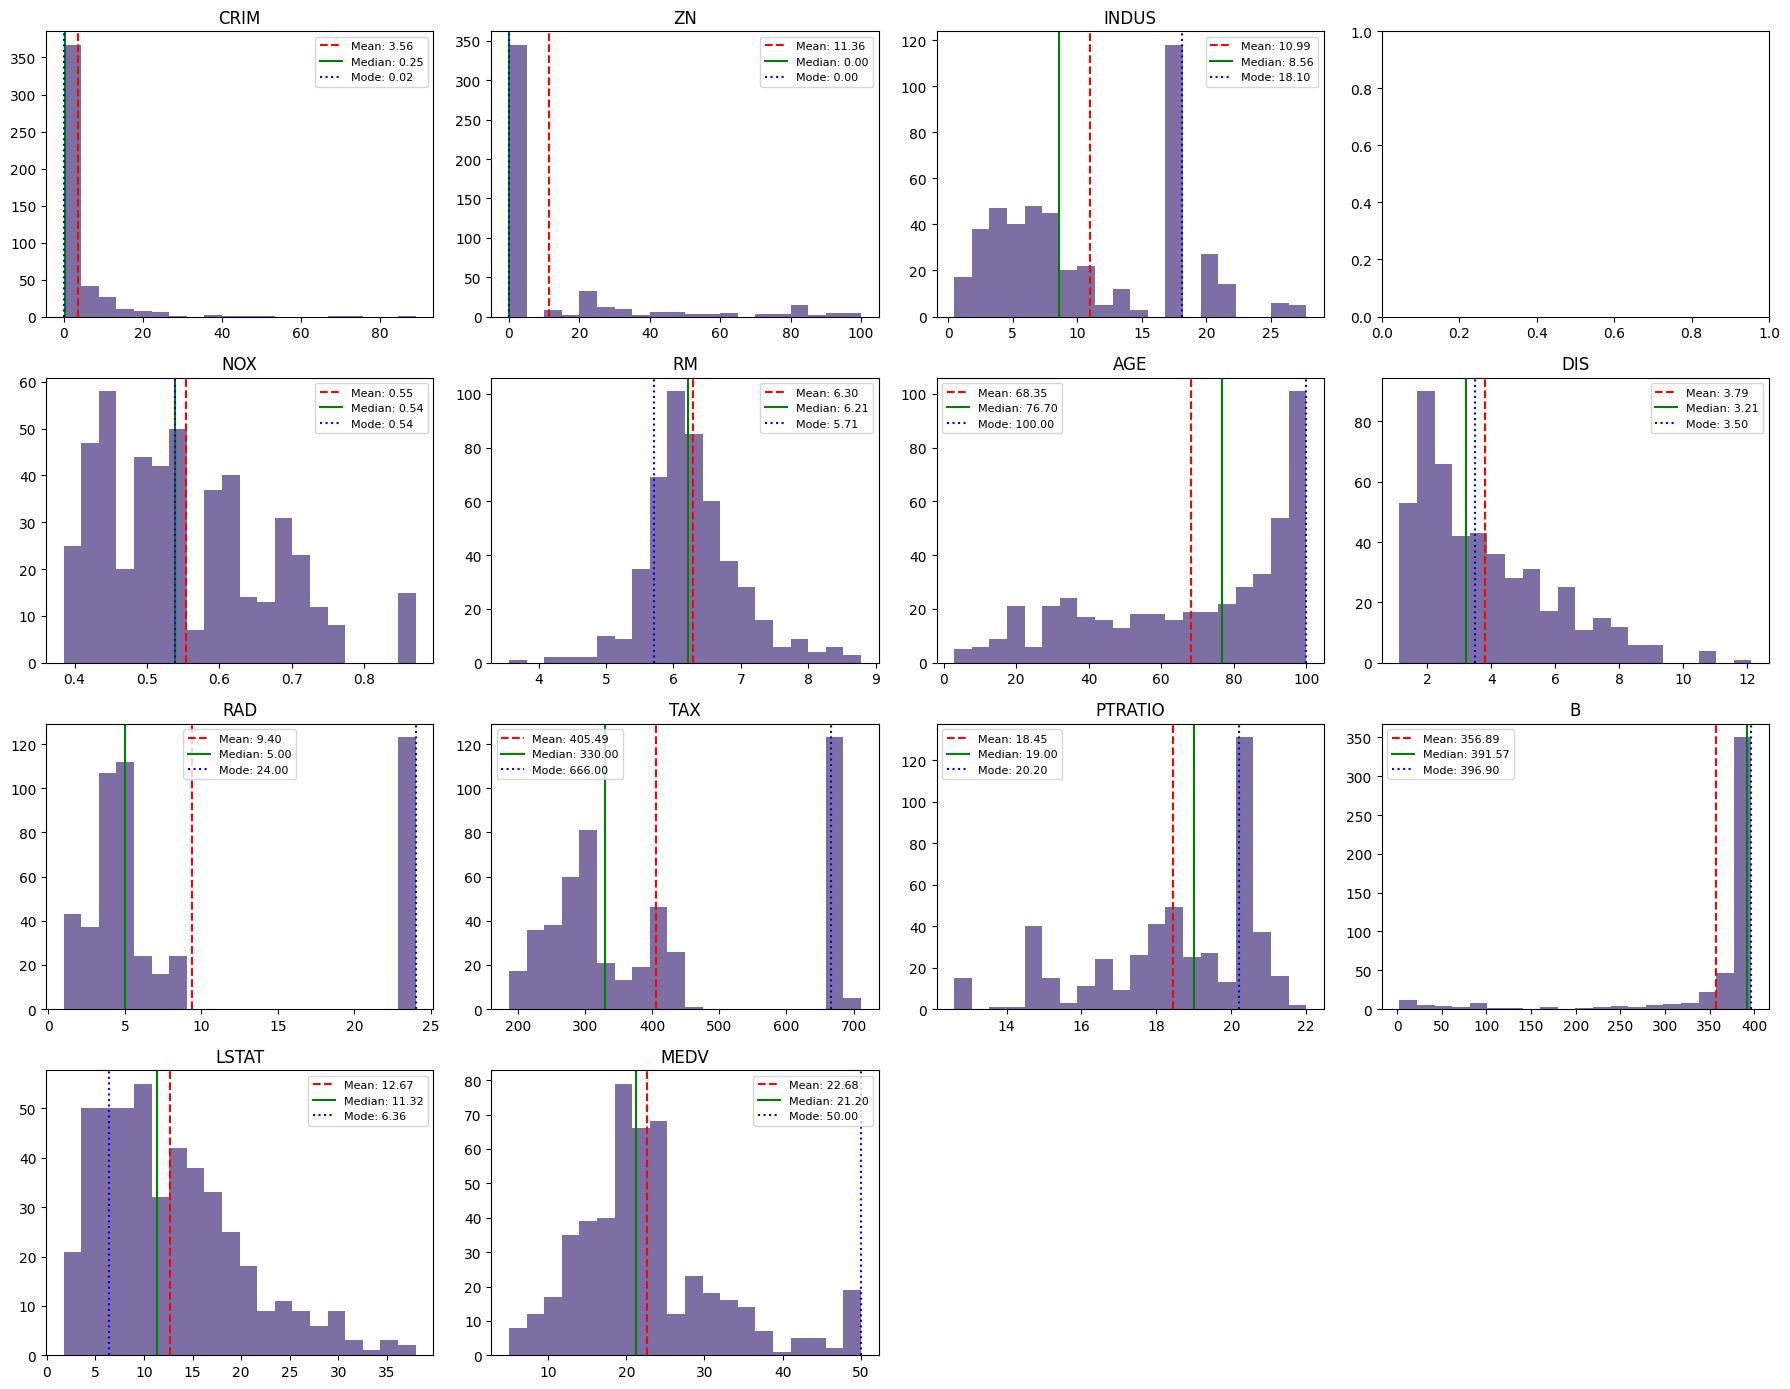

In [10]:
n_cols = 4
n_rows = int(np.ceil(len(df_bh.columns) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axs = axs.flatten()

for col, ax in zip(df_bh.columns, axs):
    if col == 'CHAS':
      continue

    data = df_bh[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(df_bh.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

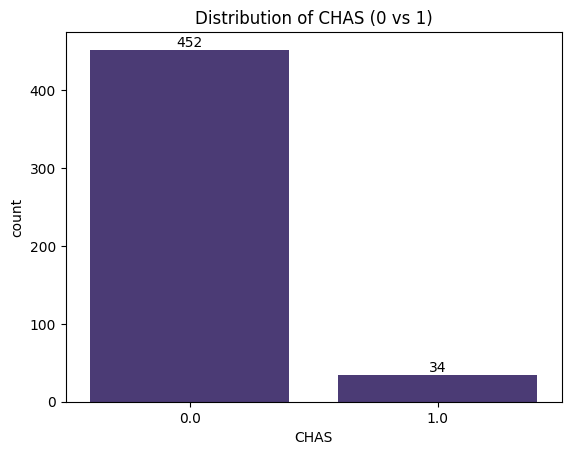

In [11]:
ax = sns.countplot(x=df_bh['CHAS'])

ax.bar_label(ax.containers[0])

plt.title('Distribution of CHAS (0 vs 1)')
plt.show()

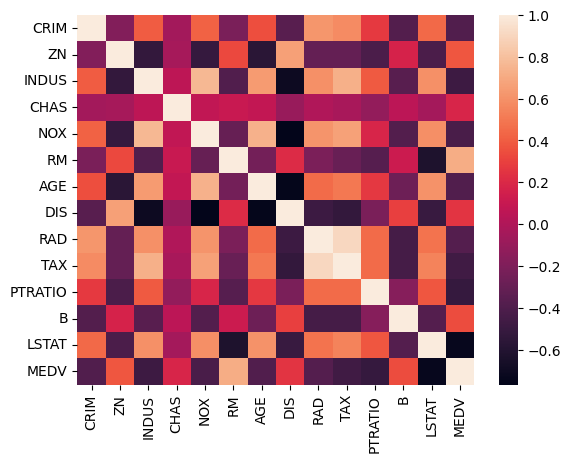

In [12]:
sns.heatmap(df_bh.corr())
plt.show()

Looks like an old colourful carpet...

But actually, it shows that the features almost don't correlate with the target.

In [13]:
df_bh.corr().CHAS.sort_values(ascending=False)

,CHAS
CHAS,1.000000
MEDV,0.181391
RM,0.104885
AGE,0.078831
NOX,0.075097
INDUS,0.059859
B,0.051264
RAD,0.001468
TAX,-0.032304
ZN,-0.037229


## Dataset 2

In [14]:
df_emt.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [15]:
df_emt.drop(['profile_id'], axis=1, inplace=True)

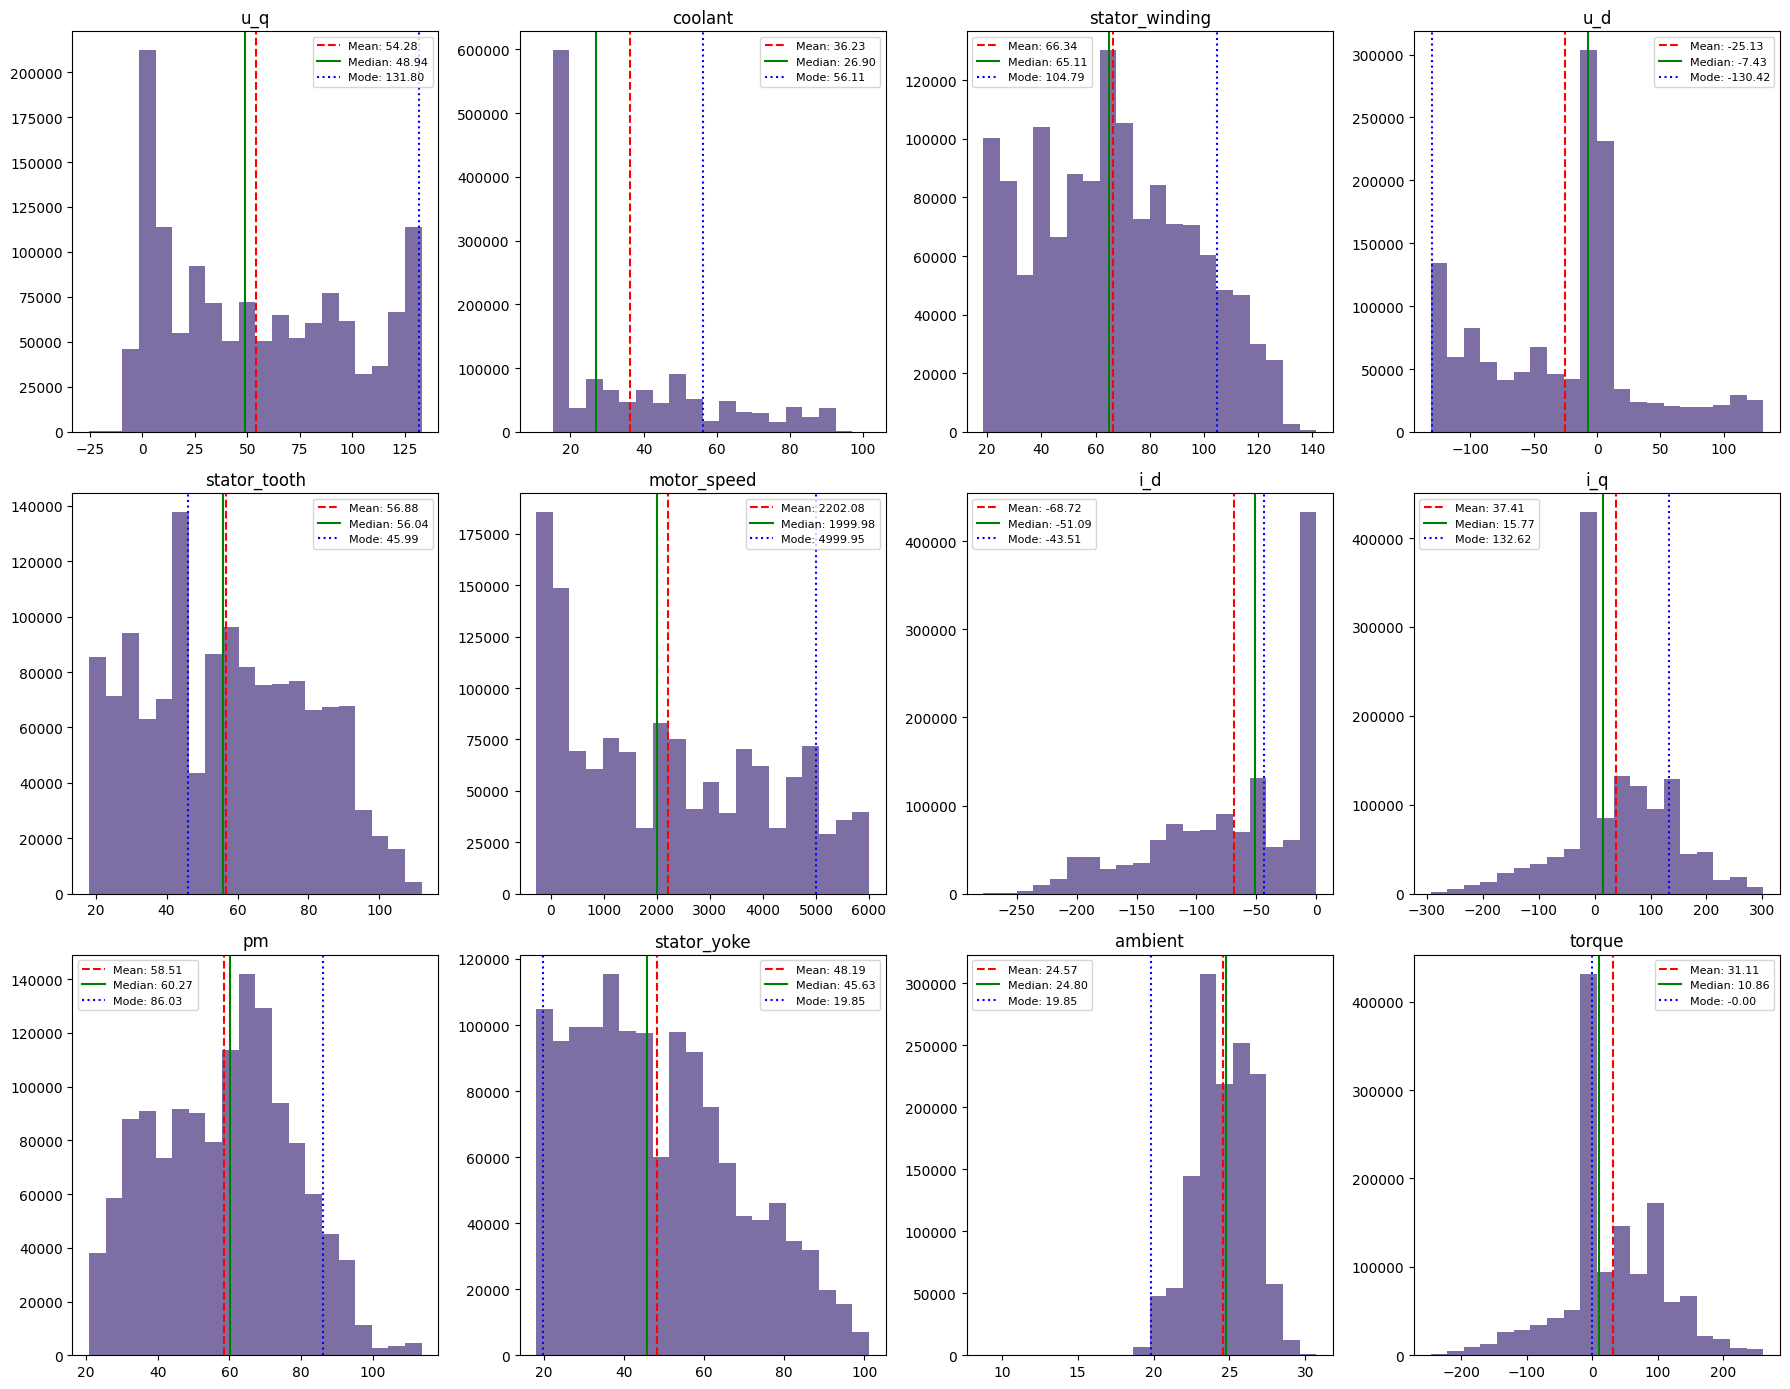

In [16]:
n_cols = 4
n_rows = int(np.ceil(len(df_emt.columns) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axs = axs.flatten()

for col, ax in zip(df_emt.columns, axs):
    data = df_emt[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(df_emt.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

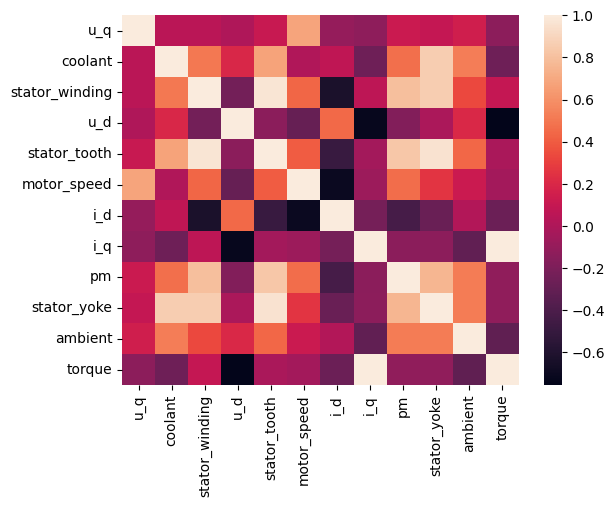

In [17]:
sns.heatmap(df_emt.corr())
plt.show()

## Dataset 3

In [18]:
drop_cols = ['address', 'district']

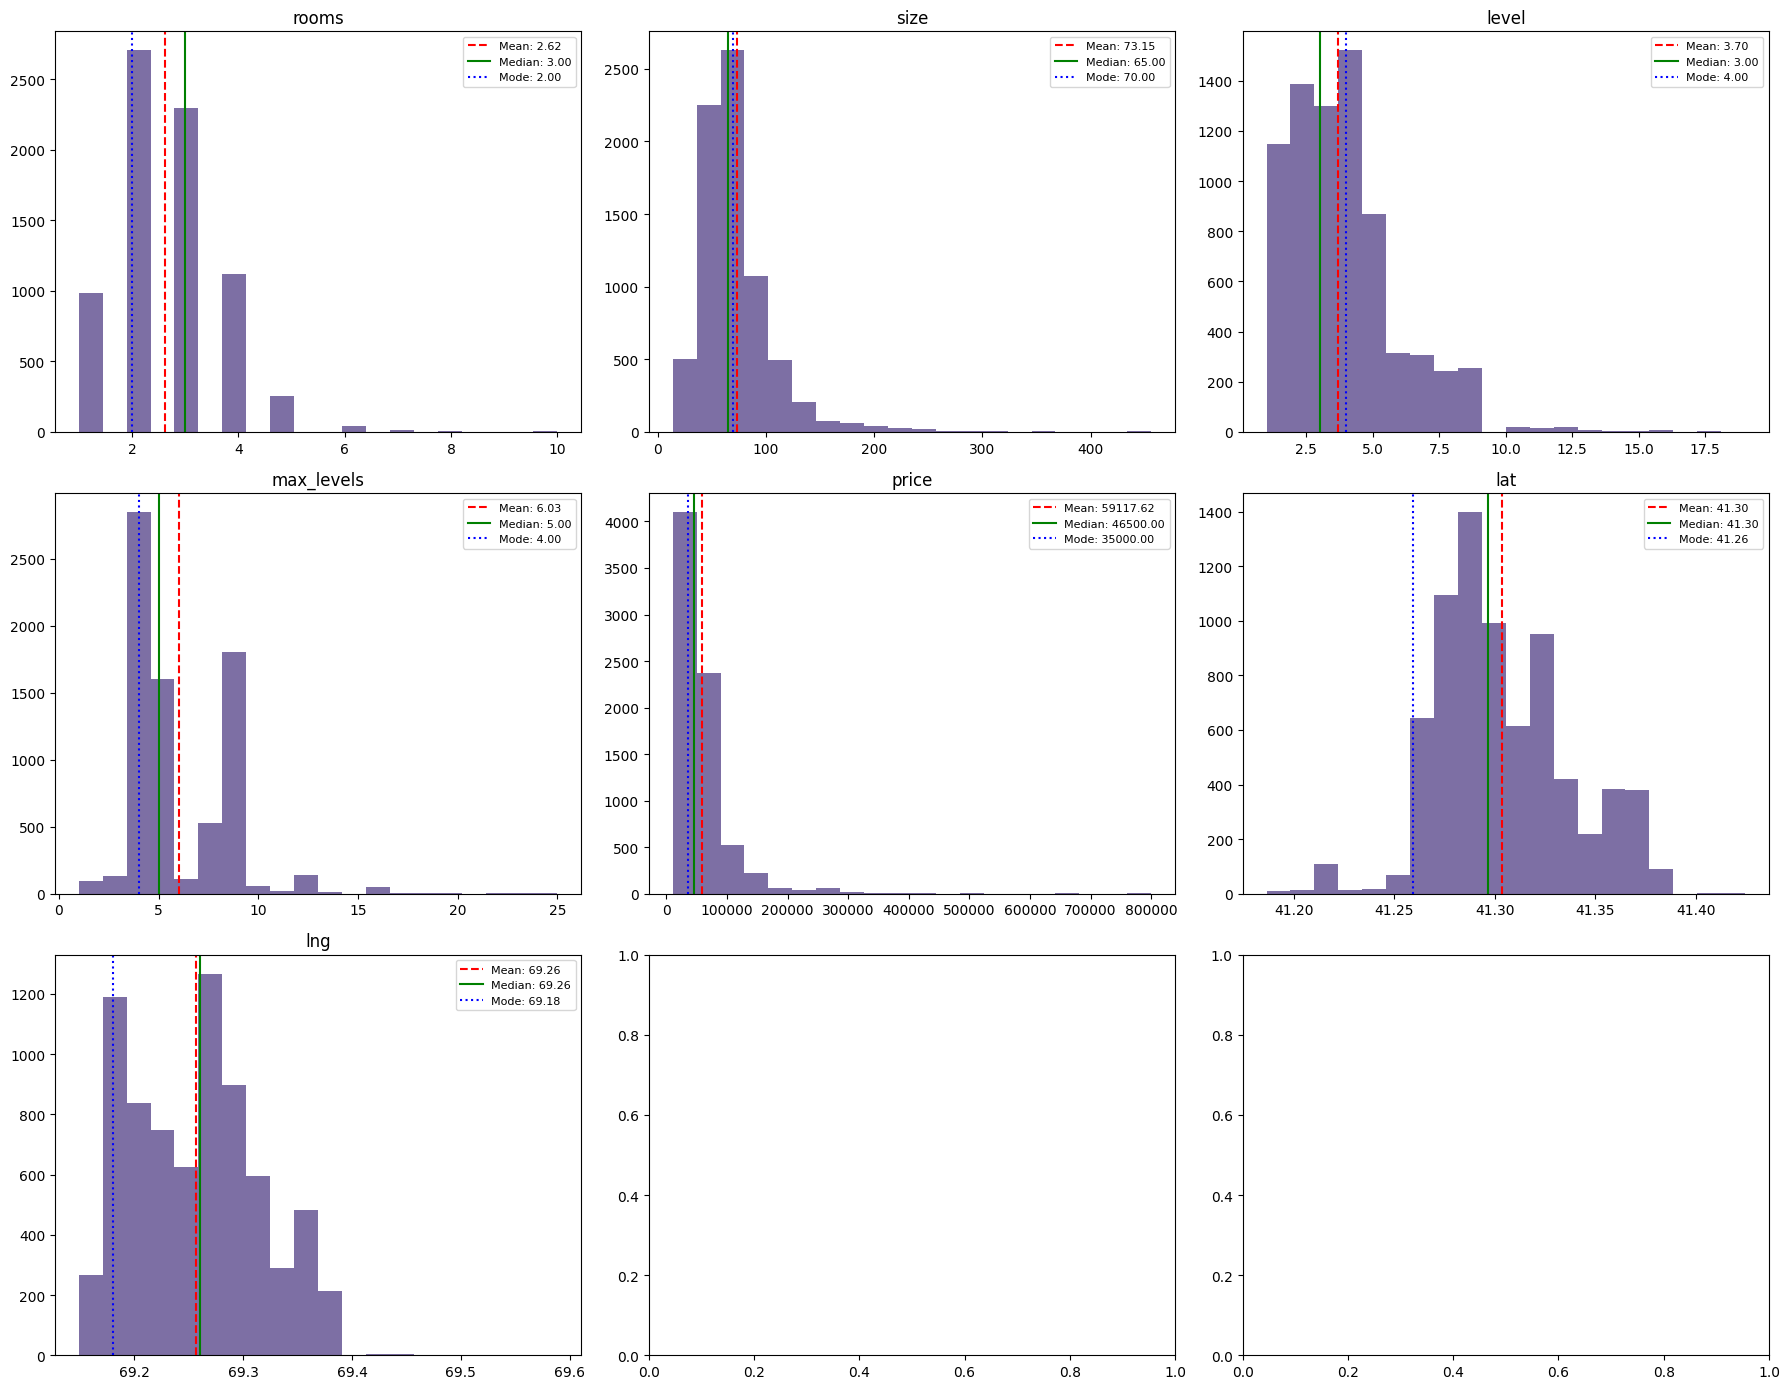

In [19]:
n_cols = 3
all_cols = df_tuh.columns.copy().drop(drop_cols)
n_rows = int(np.ceil(len(all_cols) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axs = axs.flatten()

for col, ax in zip(all_cols, axs):
    data = df_tuh[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(df_tuh.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

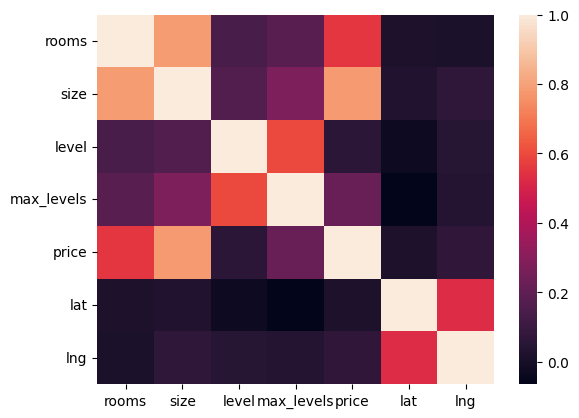

In [20]:
sns.heatmap(df_tuh[all_cols].corr())
plt.show()

## **Split Dataset**

In [21]:
X = df_bh.drop('CHAS', axis=1)
y = df_bh['CHAS']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
X = df_emt.drop(['pm'], axis=1)
y = df_emt['pm']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
lbl_encoder = LabelEncoder()

for col in drop_cols:
    df_tuh[col] = lbl_encoder.fit_transform(df_tuh[col])

In [24]:
X = df_tuh.drop(['price'], axis=1)
y = df_tuh['price']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.2, random_state=42)

## **Handle Missing Values and Scale**

In [25]:
std_scaler = StandardScaler()
imputer = KNNImputer();

X_train1 = pd.DataFrame(std_scaler.fit_transform(imputer.fit_transform(X_train1.values)), columns=X_test1.columns)
X_test1 = pd.DataFrame(std_scaler.transform(imputer.transform(X_test1.values)), columns=X_test1.columns)

In [26]:
std_scaler = StandardScaler()

X_train2 = pd.DataFrame(std_scaler.fit_transform(X_train2), columns=X_train2.columns)
X_test2 = pd.DataFrame(std_scaler.transform(X_test2), columns=X_test2.columns)

In [27]:
tg_transformer = TargetImputationTransformer()

col_indices = [X_train3.columns.get_loc(c) for c in drop_cols]

tg_transformer = TargetImputationTransformer(index=col_indices)

X_train3 = pd.DataFrame(tg_transformer.fit_transform(
  X=X_train3.values,
  y=y_train3.values),
  columns = X_train3.columns
)

X_test3 = pd.DataFrame(tg_transformer.transform(X_test3.values),
    columns = X_test3.columns
    )

In [28]:
std_scaler = StandardScaler().set_output(transform="pandas")

X_train3 = std_scaler.fit_transform(X_train3)
X_test3 = std_scaler.transform(X_test3)

# **Feature Selection**

## **Initial Dataset Performance**

In [29]:
sm = SMOTE(random_state=42)

X_sm, y_sm = sm.fit_resample(X_train1, y_train1)

In [30]:
lr = LogisticRegression(random_state=42)

lr.fit(X_sm, y_sm)
y_pred = lr.predict(X_test1)
print('Score for initial data df_bh: ', f1_score(y_pred, y_test1))

Score for initial data df_bh:  0.3125


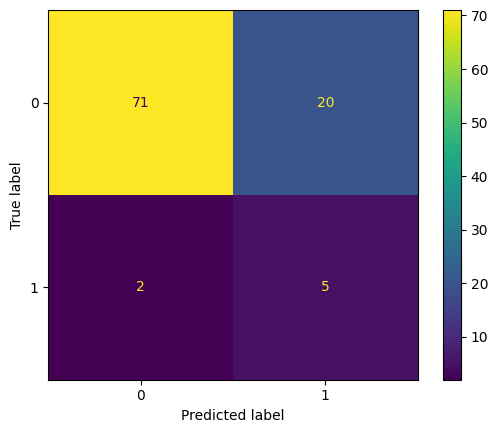

In [31]:
cm = confusion_matrix(y_test1, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

In [32]:
lr = LinearRegression()

lr.fit(X_train2, y_train2)
print('Score for initial data df_emt: ', lr.score(X_test2, y_test2))

Score for initial data df_emt:  0.8545756083091557


In [33]:
lr = LinearRegression()

lr.fit(X_train3, y_train3)
print('Score for initial data df_tuh: ', lr.score(X_test3, y_test3))

Score for initial data df_tuh:  0.6109952845576021


## **PValue**

### Dataset 1

In [34]:
pvalue_selector = PValueSelector()

df_train = pd.concat([X_train1.reset_index(drop=True), y_test1.reset_index(drop=True)], axis=1)

selected_cols = pvalue_selector.select(df_train, 'CHAS')

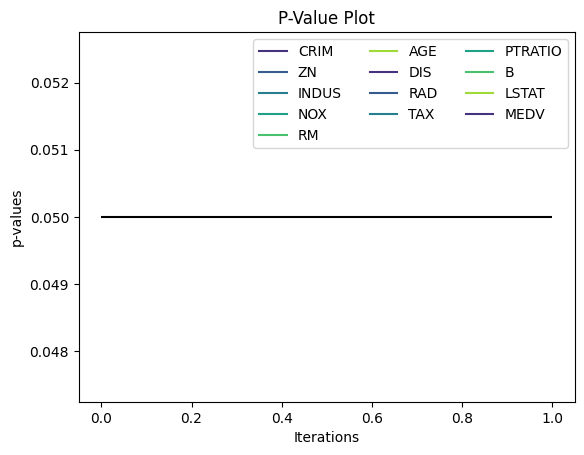

In [35]:
pvalue_selector.plot_process()

In [36]:
sm = SMOTE(random_state=42)

X_sm, y_sm = sm.fit_resample(X_train1[selected_cols], y_train1)

In [37]:
lr = LogisticRegression(random_state=42)

lr.fit(X_sm[selected_cols], y_sm)
y_pred = lr.predict(X_test1[selected_cols])
print('Score for pvalue data df_bh: ', f1_score(y_pred, y_test1))

Score for pvalue data df_bh:  0.3125


The performance has improved 31% -> 33%. Pretty strange - no cols were removed and the same random state was used...

Still bad, but better than the initial.

By p-values, we see that generally there is 0.5 probability that there is practically no relatioinship between features and the target.

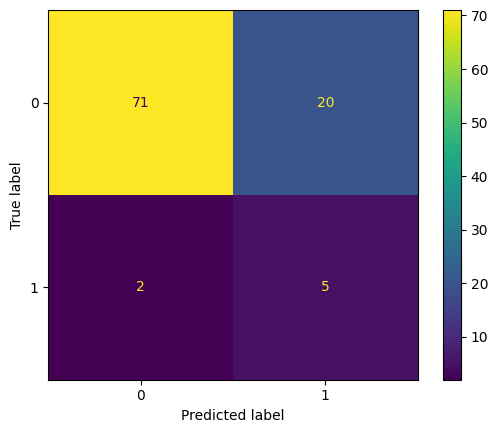

In [38]:
cm = confusion_matrix(y_test1, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

The number of true positives and true negatives has increased - nice

### Dataset 2

In [39]:
pvalue_selector = PValueSelector()

df_train2 = pd.concat([X_train2.reset_index(drop=True), y_train2.reset_index(drop=True)], axis=1)

selected_cols = pvalue_selector.select(df_train2, 'pm')

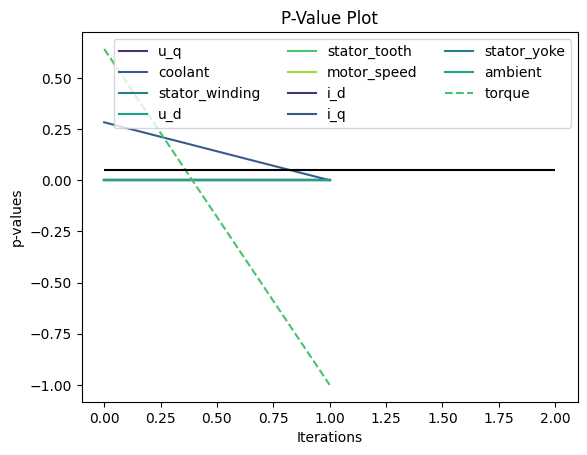

In [40]:
pvalue_selector.plot_process()

By p-values, torque has been considered an irrelevant feature.

In [41]:
lr = LinearRegression()

lr.fit(X_train2[selected_cols], y_train2)
print('Score for pvalue data df_bh: ', lr.score(X_test2[selected_cols], y_test2))

Score for pvalue data df_bh:  0.8545760104764019


Actually, the score even improved a bit! It means that torque doesn't have any effect on the pm, only giving pointless information.

### Dataset 3

In [42]:
pvalue_selector = PValueSelector()

df_train3 = pd.concat([X_train3.reset_index(drop=True), y_train3.reset_index(drop=True)], axis=1)

selected_cols = pvalue_selector.select(df_train3, 'price')

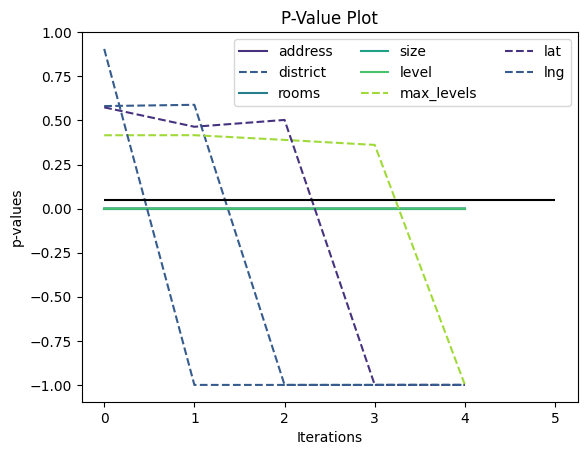

In [43]:
pvalue_selector.plot_process()

p-values feature selector has removed half of the features, considering them meaningless.

In [44]:
lr = LinearRegression()

lr.fit(X_train3[selected_cols], y_train3)
print('Score for pvalue data df_tuh: ', lr.score(X_test3[selected_cols], y_test3))

Score for pvalue data df_tuh:  0.6077110626263649


Having reduced the number of features by half, it is impressive. We lost <1% of information, but the number of dimensions is 4 instead of 8. It is nice, and I think it is reasonable to use only those.

## **Lasso Selector**

### Dataset 2

In [45]:
lasso = LassoSelector()

selected_cols = lasso.select(df_train2, 'pm')

In [46]:
selected_cols

['u_q',
 'coolant',
 'stator_winding',
 'u_d',
 'stator_tooth',
 'motor_speed',
 'i_d',
 'i_q',
 'stator_yoke',
 'ambient',
 'torque']

Lasso hadn't found anything insignificant.

In [47]:
lasso.plot_process()

TypeError: too many positional arguments

doesn't work :(

In [48]:
lr = LinearRegression()

lr.fit(X_train2[selected_cols], y_train2)
print('Score for lasso data df_bh: ', lr.score(X_test2[selected_cols], y_test2))

Score for lasso data df_bh:  0.8545756083091557


Nothing removed, nothing changed.

### Dataset 3

In [49]:
lasso = LassoSelector()

selected_cols = lasso.select(df_train3, 'price')

In [50]:
selected_cols

['address', 'district', 'rooms', 'size', 'level', 'max_levels', 'lat', 'lng']

Again, it selected all the columns

In [ ]:
lasso.plot_process()

same :(

In [51]:
lr = LinearRegression()

lr.fit(X_train3[selected_cols], y_train3)
print('Score for lasso data df_tuh: ', lr.score(X_test3[selected_cols], y_test3))

Score for lasso data df_tuh:  0.6109952845576021


Nothing

## **Pearson Correlation Selector**

### Dataset 2

In [52]:
pearson = PearsonCorrelationSelector()

selected_cols = pearson.select(df_train2, 'pm')

In [53]:
selected_cols

['stator_winding', 'stator_yoke', 'ambient']

It found pearson correlation only between 3 features and the target. Pretty harsh selection.

In [54]:
lr = LinearRegression()

lr.fit(X_train2[selected_cols], y_train2)
print('Score for pearson correlation data df_emt: ', lr.score(X_test2[selected_cols], y_test2))

Score for pearson correlation data df_emt:  0.703363515338433


The results dropped by 15%. Quite interesting that those 3/11 give 70% of the result.

### Dataset 3

In [55]:
pearson = PearsonCorrelationSelector()

selected_cols = pearson.select(df_train3, 'price')

In [56]:
selected_cols

['address', 'rooms', 'size']

Only 3/8 were selected.

In [57]:
lr = LinearRegression()

lr.fit(X_train3[selected_cols], y_train3)
print('Score for pearson correlation data df_tuh: ', lr.score(X_test3[selected_cols], y_test3))

Score for pearson correlation data df_tuh:  0.5979812720421784


In comparison with initial one, the results dropped by 2%,

## **Kendall Correlation Selector**

### Dataset 2

In [97]:
kendall = KendallCorrelationSelector()

selected_cols = kendall.select(df_train2, 'pm')

In [98]:
selected_cols

['stator_winding', 'stator_tooth', 'stator_yoke']

It found kendall correlation only between 3 features and the target, but different to which pearson found.

In [99]:
lr = LinearRegression()

lr.fit(X_train2[selected_cols], y_train2)
print('Score for kendall correlation data df_emt: ', lr.score(X_test2[selected_cols], y_test2))

Score for kendall correlation data df_emt:  0.8068639988239431


The results dropped by 5%. Actually, it worked out better than pearson! Reducing dimension almost 3 times and almost preserving the information looks cool! For really large datasets, it would be vital.

### Dataset 3

In [100]:
kendall = KendallCorrelationSelector()

selected_cols = kendall.select(df_train3, 'price')

In [101]:
selected_cols

['address', 'rooms', 'size']

Only 3/8 were selected.

In [102]:
lr = LinearRegression()

lr.fit(X_train3[selected_cols], y_train3)
print('Score for kendall correlation data df_tuh: ', lr.score(X_test3[selected_cols], y_test3))

Score for kendall correlation data df_tuh:  0.5979812720421784


Same as with pearson correlation.

## **Spearman Correlation Selector**

### Dataset 2

In [103]:
spearman = SpearmanCorrelationSelector()

selected_cols = spearman.select(df_train2, 'pm')

In [104]:
selected_cols

['coolant', 'stator_winding', 'stator_yoke', 'ambient']

It found spearman correlation between 4 features.

In [106]:
lr = LinearRegression()

lr.fit(X_train2[selected_cols], y_train2)
print('Score for spearman correlation data df_emt: ', lr.score(X_test2[selected_cols], y_test2))

Score for spearman correlation data df_emt:  0.7497555738986034


It worked somewhat between pearson and kendall, but had chosen 4 features, which is quite bad.

### Dataset 3

In [107]:
spearman = SpearmanCorrelationSelector()

selected_cols = spearman.select(df_train3, 'price')

In [108]:
selected_cols

['address', 'rooms']

Only 2/8 were selected.

In [109]:
lr = LinearRegression()

lr.fit(X_train3[selected_cols], y_train3)
print('Score for spearman correlation data df_tuh: ', lr.score(X_test3[selected_cols], y_test3))

Score for spearman correlation data df_tuh:  0.27814009322895705


It was even harsher... The results dropped, but it is interesting that even so it is not that much.

## **Point Biserial Correlation**

### Dataset 1

In [88]:
point_biserial = PointBiserialCorrSelector()

selected_cols = point_biserial.select(df_train, 'CHAS')

In [89]:
selected_cols

['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

As a result, only 1 feature was removed.

In [94]:
lr = LogisticRegression(random_state=42)

lr.fit(X_sm[selected_cols], y_sm)
y_pred = lr.predict(X_test1[selected_cols])
print('Score for point biserial correlation data df_bh: ', f1_score(y_pred, y_test1))

Score for point biserial correlation data df_bh:  0.3125


The result hadn't changed, so in that feature was no important information.

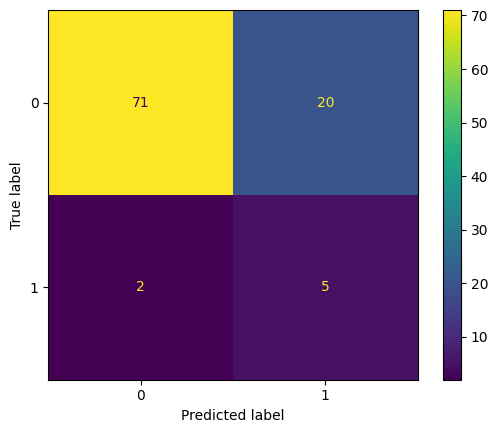

In [95]:
cm = confusion_matrix(y_test1, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Actually, it started to predict better true positives - great!

# **Conclusion**

Why do we need all those algorithms for feature selection? They help us sort out only the important features, reducing dimensions(and models complexity respectively).

How can it help me? Instead of trying to train models on all of the permutations of features(which will take 2^d), it is more useful to compute it either based on correlation, p-values, or regularization.